In [47]:
!pip install opencv-python librosa matplotlib numpy pandas scipy
!pip install openai-whisper
!pip install sentence-transformers

In [48]:
import cv2
import librosa
import whisper
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import os

from scipy.spatial.distance import cosine
from sentence_transformers import SentenceTransformer

In [49]:
INPUT_VIDEO = "/kaggle/input/datasets/ravigiri20027/jj-clip/TRY_NOT_TO_LAUGH_African_Edition_2_720P.mp4"

PROCESSED_VIDEO = "processed.mp4"
AUDIO_FILE = "audio.wav"

# resize + normalize fps
subprocess.run([
    "ffmpeg",
    "-y",
    "-i",
    INPUT_VIDEO,
    "-vf",
    "scale=640:360",
    "-r",
    "24",
    PROCESSED_VIDEO
])

# extract mono audio
subprocess.run([
    "ffmpeg",
    "-y",
    "-i",
    PROCESSED_VIDEO,
    "-ar",
    "16000",
    "-ac",
    "1",
    AUDIO_FILE
])

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

CompletedProcess(args=['ffmpeg', '-y', '-i', 'processed.mp4', '-ar', '16000', '-ac', '1', 'audio.wav'], returncode=0)

In [50]:
model = whisper.load_model("base")

result = model.transcribe(AUDIO_FILE)

segments = result["segments"]

transcript_df = pd.DataFrame([
    {
        "start": s["start"],
        "end": s["end"],
        "text": s["text"]
    }
    for s in segments
])

transcript_df.head()

,start,end,text
0,0.00,2.56,"Yo, what's up? It's WakerSyalahGDMET."
1,2.56,4.24,The end of the year is near.
2,4.24,9.20,"So of course, we have to squeeze out some mor..."
3,9.20,11.52,"Uh, we got a batch of funny clips."
4,11.52,13.44,"You know, I mean, you already know how these ..."


In [51]:
cap = cv2.VideoCapture(PROCESSED_VIDEO)

motion_scores = []

prev = None
frame_idx = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    # skip frames for speed
    if frame_idx % 5 != 0:
        frame_idx += 1
        continue

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if prev is not None:
        diff = cv2.absdiff(prev, gray)
        motion = diff.mean()
        motion_scores.append(motion)

    prev = gray
    frame_idx += 1

cap.release()

print("Motion samples:", len(motion_scores))

Motion samples: 3641


In [52]:
y, sr = librosa.load(AUDIO_FILE)

rms = librosa.feature.rms(y=y)[0]

times = librosa.times_like(rms)

silence_threshold = 0.02

silence_regions = rms < silence_threshold

avg_energy = np.mean(rms)

print("Average Energy:", avg_energy)

Average Energy: 0.07717012


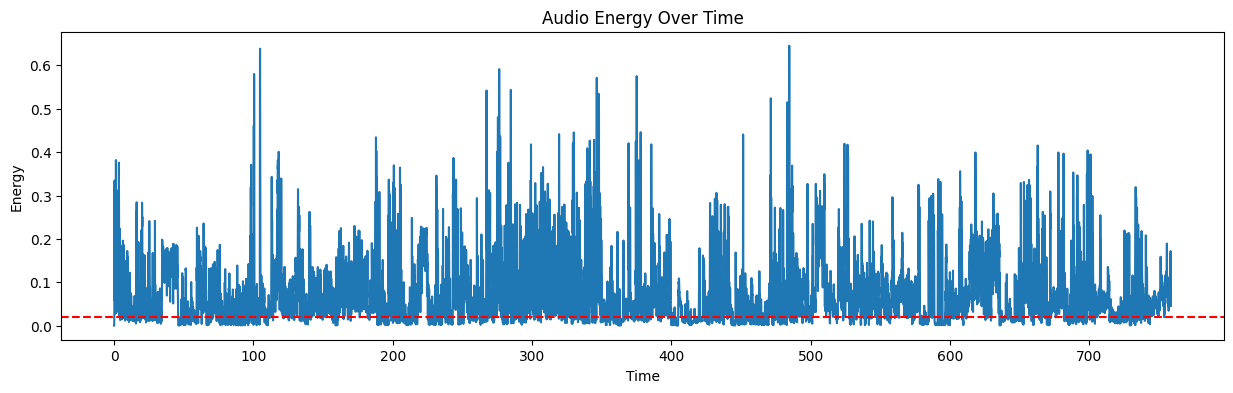

In [53]:
plt.figure(figsize=(15,4))

plt.plot(times, rms)

plt.axhline(
    silence_threshold,
    color='r',
    linestyle='--'
)

plt.title("Audio Energy Over Time")
plt.xlabel("Time")
plt.ylabel("Energy")

plt.show()

In [54]:
def classify_silence(index, rms, window=10):

    before = np.mean(rms[max(0, index-window):index])

    after = np.mean(rms[index:index+window])

    if before > 0.08 and after > 0.08:
        return "dramatic_pause"

    elif before < 0.03 and after < 0.03:
        return "dead_silence"

    else:
        return "neutral_pause"


silence_analysis = []

for i, silent in enumerate(silence_regions):

    if silent:
        silence_analysis.append({
            "time": float(times[i]),
            "type": classify_silence(i, rms)
        })

pd.DataFrame(silence_analysis).head()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


,time,type
0,0.00000,neutral_pause
1,0.02322,neutral_pause
2,0.04644,neutral_pause
3,0.06966,neutral_pause
4,0.09288,neutral_pause


In [55]:
embedder = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

embeddings = embedder.encode(
    transcript_df["text"].tolist()
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


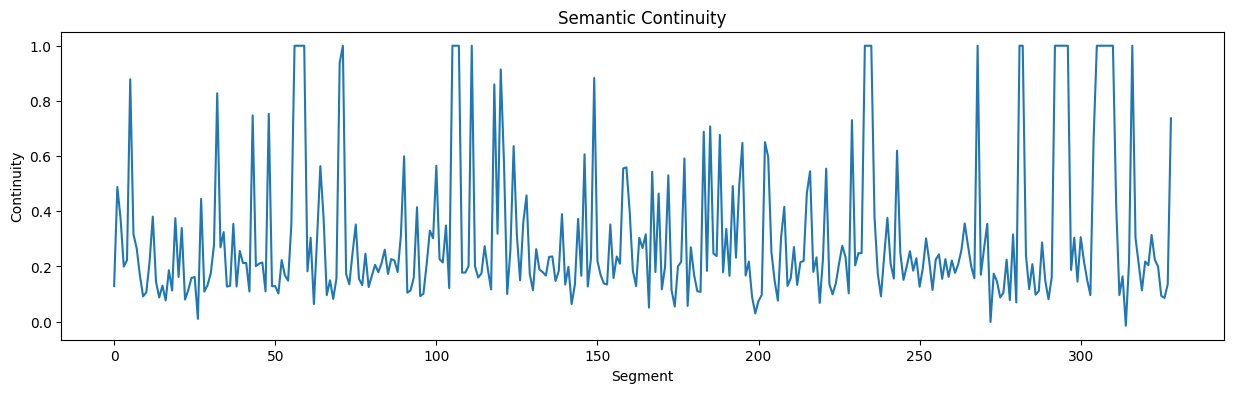

In [56]:
continuity_scores = []

for i in range(1, len(embeddings)):

    similarity = 1 - cosine(
        embeddings[i-1],
        embeddings[i]
    )

    continuity_scores.append(similarity)

plt.figure(figsize=(15,4))

plt.plot(continuity_scores)

plt.title("Semantic Continuity")
plt.xlabel("Segment")
plt.ylabel("Continuity")

plt.show()

In [57]:
hook_text = " ".join(
    transcript_df[
        transcript_df["start"] < 15
    ]["text"].tolist()
)

print(hook_text)

 Yo, what's up? It's WakerSyalahGDMET.  The end of the year is near.  So of course, we have to squeeze out some more trying not to laugh before the end of the year.  Uh, we got a batch of funny clips.  You know, I mean, you already know how these girls.  I'm gonna try not to laugh. I'm gonna laugh.


In [58]:
attention_curve = []

previous_attention = 85

for i in range(min(
    len(motion_scores),
    len(rms)
)):

    # ------------------------
    # BASE ATTENTION
    # ------------------------

    attention_delta = 0

    motion = motion_scores[i]
    audio_energy = rms[i]

    # ------------------------
    # VISUAL EFFECT
    # ------------------------

    if motion < 8:
        attention_delta -= 4

    elif motion > 30:
        attention_delta += 2

    # ------------------------
    # AUDIO EFFECT
    # ------------------------

    if audio_energy < silence_threshold:
        attention_delta -= 3

    elif audio_energy > 0.08:
        attention_delta += 2

    # ------------------------
    # SEMANTIC CONTINUITY
    # ------------------------

    if i < len(continuity_scores):

        continuity = continuity_scores[i]

        if continuity < 0.3:
            attention_delta -= 5

        elif continuity > 0.7:
            attention_delta += 2

    # ------------------------
    # MOMENTUM / INERTIA
    # ------------------------

    # Human attention changes gradually
    # not instantly.

    new_attention = (
        previous_attention * 0.85
        +
        (previous_attention + attention_delta) * 0.15
    )

    # clamp
    new_attention = max(0, min(100, new_attention))

    attention_curve.append(new_attention)

    previous_attention = new_attention

In [59]:
def moving_average(data, window_size=8):

    smoothed = []

    for i in range(len(data)):

        start = max(0, i - window_size)

        end = min(len(data), i + window_size)

        avg = np.mean(data[start:end])

        smoothed.append(avg)

    return smoothed


smoothed_attention_curve = moving_average(
    attention_curve,
    window_size=25
)

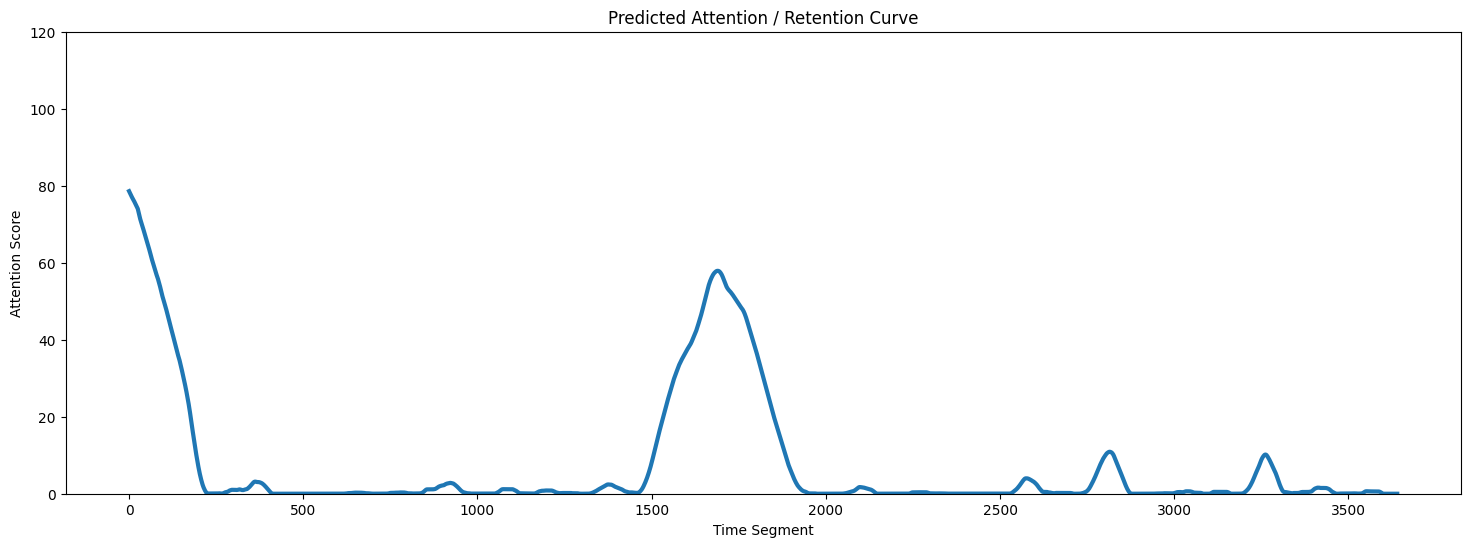

In [60]:
plt.figure(figsize=(18,6))

# plt.plot(attention_curve)
plt.plot(smoothed_attention_curve, linewidth=3)

plt.title("Predicted Attention / Retention Curve")
plt.xlabel("Time Segment")
plt.ylabel("Attention Score")

plt.ylim(0, 120)

plt.show()

In [61]:
drops = []

for i in range(1, len(attention_curve)):

    diff = attention_curve[i] - attention_curve[i-1]

    if diff < -10:

        drops.append({
            "segment": i,
            "drop": diff
        })

pd.DataFrame(drops)

""


In [62]:
suggestions = []

for d in drops:

    idx = d["segment"]

    msg = f"""
    Attention drop near segment {idx}:
    """

    if motion_scores[idx] < 8:
        msg += "\n- low visual novelty"

    if rms[idx] < silence_threshold:
        msg += "\n- silence may lack payoff"

    if idx < len(continuity_scores):

        if continuity_scores[idx] < 0.3:
            msg += "\n- topic continuity weak"

    suggestions.append(msg)

for s in suggestions:
    print(s)

In [63]:
# -----------------------------
# FINAL REPORT
# -----------------------------

curve = smoothed_attention_curve

total_length = len(curve)

start_section = curve[:total_length // 3]
middle_section = curve[
    total_length // 3 : 2 * total_length // 3
]
end_section = curve[
    2 * total_length // 3 :
]

start_avg = np.mean(start_section)
middle_avg = np.mean(middle_section)
end_avg = np.mean(end_section)

overall_avg = np.mean(curve)

# -----------------------------
# ATTENTION TREND
# -----------------------------

trend = end_avg - start_avg

if trend > 5:
    trend_text = "Attention improves throughout the video."

elif trend < -5:
    trend_text = "Attention gradually declines over time."

else:
    trend_text = "Attention remains relatively stable."

# -----------------------------
# HOOK ANALYSIS
# -----------------------------

if start_avg > 80:
    hook_quality = "Strong opening hook."

elif start_avg > 60:
    hook_quality = "Moderately engaging opening."

else:
    hook_quality = "Weak opening hook."

# -----------------------------
# MID SECTION
# -----------------------------

if middle_avg < start_avg - 10:
    middle_text = (
        "Middle section loses momentum."
    )

else:
    middle_text = (
        "Middle section maintains attention reasonably well."
    )

# -----------------------------
# ENDING ANALYSIS
# -----------------------------

if end_avg > middle_avg:
    ending_text = (
        "Ending successfully regains attention."
    )

elif end_avg < middle_avg - 10:
    ending_text = (
        "Ending loses emotional or narrative momentum."
    )

else:
    ending_text = (
        "Ending maintains acceptable engagement."
    )

# -----------------------------
# SILENCE ANALYSIS
# -----------------------------

dramatic_pauses = sum(
    1 for s in silence_analysis
    if s["type"] == "dramatic_pause"
)

dead_silences = sum(
    1 for s in silence_analysis
    if s["type"] == "dead_silence"
)

if dramatic_pauses > dead_silences:
    silence_summary = (
        "Silence usage generally supports tension and pacing."
    )

else:
    silence_summary = (
        "Several silence regions may reduce engagement."
    )

# -----------------------------
# CONTINUITY ANALYSIS
# -----------------------------

avg_continuity = np.mean(continuity_scores)

if avg_continuity > 0.7:
    continuity_text = (
        "Narrative continuity is strong."
    )

elif avg_continuity > 0.5:
    continuity_text = (
        "Narrative continuity is moderate."
    )

else:
    continuity_text = (
        "Narrative flow feels fragmented."
    )

# -----------------------------
# FINAL SCORE
# -----------------------------

final_score = (
    overall_avg * 0.5
    +
    avg_continuity * 50 * 0.3
    +
    (1 - dead_silences / max(1, len(silence_analysis))) * 20
)

final_score = round(
    max(0, min(100, final_score)),
    2
)

# -----------------------------
# PRINT REPORT
# -----------------------------

print("\n")
print("=" * 60)
print("VIDEO ATTENTION REPORT")
print("=" * 60)

print(f"\nOverall Attention Score: {final_score}/100")

print("\n--- SECTION SCORES ---")

print(f"Start Section Avg:  {start_avg:.2f}")
print(f"Middle Section Avg: {middle_avg:.2f}")
print(f"End Section Avg:    {end_avg:.2f}")

print("\n--- SUMMARY ---")

print(f"- {hook_quality}")
print(f"- {middle_text}")
print(f"- {ending_text}")

print(f"- {trend_text}")

print(f"- {silence_summary}")

print(f"- {continuity_text}")

print("\n--- SILENCE BREAKDOWN ---")

print(f"Dramatic pauses: {dramatic_pauses}")
print(f"Dead silences:   {dead_silences}")

print("\n--- CONTINUITY ---")

print(f"Average semantic continuity: {avg_continuity:.2f}")

print("\n--- RECOMMENDATIONS ---")

if start_avg < 65:
    print("- Improve the first 15 seconds with stronger curiosity.")

if middle_avg < 60:
    print("- Add more payoff moments in the middle section.")

if dead_silences > dramatic_pauses:
    print("- Reduce unintentional silence or improve pacing.")

if avg_continuity < 0.5:
    print("- Improve narrative transitions between ideas.")

if overall_avg < 60:
    print("- Increase emotional variation and visual novelty.")

print("\n")
print("=" * 60)



VIDEO ATTENTION REPORT

Overall Attention Score: 16.69/100

--- SECTION SCORES ---
Start Section Avg:  8.48
Middle Section Avg: 12.17
End Section Avg:    1.47

--- SUMMARY ---
- Weak opening hook.
- Middle section maintains attention reasonably well.
- Ending loses emotional or narrative momentum.
- Attention gradually declines over time.
- Several silence regions may reduce engagement.
- Narrative flow feels fragmented.

--- SILENCE BREAKDOWN ---
Dramatic pauses: 65
Dead silences:   4033

--- CONTINUITY ---
Average semantic continuity: 0.31

--- RECOMMENDATIONS ---
- Improve the first 15 seconds with stronger curiosity.
- Add more payoff moments in the middle section.
- Reduce unintentional silence or improve pacing.
- Improve narrative transitions between ideas.
- Increase emotional variation and visual novelty.


